# Bank Business Models (Replication of BIS, 2014)
Este notebook reproduz a metodologia do artigo *Roengpitya, Tarashev & Tsatsaronis (2014)* para o mercado bancário brasileiro usando os dados do COSIF.

Foca-se em 3 a 4 métricas chaves em escala de proporção absoluta (sem Z-score) usando agrupamento hierárquico de Ward e o índice Calinski-Harabasz.


In [1]:
import pandas as pd
import sqlite3
import numpy as np

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')
    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']
    query = f"SELECT {', '.join(financial_indicators)} FROM balancetes_media_ano WHERE cnpj IN (SELECT cnpj FROM balancetes_media_ano GROUP BY ano, cnpj);"
    df = pd.read_sql_query(query, conn)
    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']
    for col in colunas_para_limpar:
        df[col] = df[col].str.lower().str.normalize('NFD').str.replace(r'[\u0300-\u036f]', '', regex=True)

    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    
    # Removendo contas duplicadas
    df = df[~df['conta'].isin([88000008, 47100004, 51100007, 78100004, 61000001])]

    mapa_contas = df.groupby('conta')['nome_conta'].agg(lambda x: x.value_counts().index[0]).to_dict()
    novo_mapeamento = {}
    for conta, nome in mapa_contas.items():
        conta_str = str(conta)
        if conta_str.startswith('1'): novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'): novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'): novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'): novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'): novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'): novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'): novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'): novo_nome = f"compensacao passiva - {nome}"
        else: novo_nome = nome
        novo_mapeamento[conta] = novo_nome

    df = df.pivot(index=['ano', 'cnpj', 'nome', 'taxonomia'], columns='conta', values='saldo').reset_index()
    df['ano'] = df['ano'].astype(int)

    # Filtro Ativo / Crédito para ter bancos com alguma operação
    df = df[df[16000001] > 1000000]

    # Exclusões taxonômicas (Mantidas conforme acordado)
    taxonomias_excluir = [
        'banco nacional de desenvolvimento economico social', 'bancos de desenvolvimento', 'agencias de fomento ou de desenvolvimento',
        'cooperativas de credito', 'soc. corretora de titulos e valores mobiliarios', 'soc distribuidora de titulos e valores mobiliarios',
        'sociedades de credito imobiliario', 'sociedade de credito imobiliario', 'companhias hipotecarias', 'associacao de poupanca e emprestimos',
        'sociedade de credito ao microempreendedor'
    ]
    df = df[~df['taxonomia'].isin(taxonomias_excluir)]

    colunas_para_inverter = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia']]
    for col in colunas_para_inverter:
        if pd.notna(df[col].max()) and (df[col].max() <= 0) and (df[col].min() < 0):
            df[col] = df[col] * -1

    df.fillna(0, inplace=True)
    df_original = df.copy().rename(columns=novo_mapeamento)
    
    return df_original

df_original = dados_bancos()



### Construção das Variáveis BIS


In [2]:
def criar_variaveis_bis(df_orig):
    indices = df_orig[['ano', 'cnpj', 'nome', 'taxonomia']].copy()
    
    ativo_col = 39999993 if 39999993 in df_orig.columns else 'compensacao ativa - total geral do ativo'
    if ativo_col not in df_orig.columns:
        ativo_col = [c for c in df_orig.columns if 'ativo' in str(c) and 'total' in str(c)][0]
    ativo_total = df_orig[ativo_col]
    
    # 1. Gross Loans (Empréstimos Brutos)
    col_cred = [c for c in df_orig.columns if 'operacoes de credito' in str(c) and 'provisoes' not in str(c)]
    if col_cred: indices['gross_loans'] = df_orig[col_cred[0]] / ativo_total
    
    # 2. Interbank Borrowing (Passivos Interbancários)
    cols_interbank = [c for c in df_orig.columns if 'passivo' in str(c) and ('interfinanceiro' in str(c) or 'repasses' in str(c))]
    indices['interbank_borrowing'] = df_orig[cols_interbank].sum(axis=1) / ativo_total
    
    # 3. Wholesale Debt (Dívida de Atacado / Captações de Mercado)
    cols_wholesale = [c for c in df_orig.columns if 'passivo' in str(c) and ('mercado aberto' in str(c) or 'aceites' in str(c) or 'emissao de titulos' in str(c))]
    indices['wholesale_debt'] = df_orig[cols_wholesale].sum(axis=1) / ativo_total
    
    # 4. Customer Deposits (Controle: Depósitos Varejo)
    cols_dep = [c for c in df_orig.columns if 'passivo' in str(c) and 'deposit' in str(c) and 'interfinanceiro' not in str(c)]
    indices['customer_deposits'] = df_orig[cols_dep].sum(axis=1) / ativo_total
        
    indices.fillna(0, inplace=True)
    return indices

df_bis = criar_variaveis_bis(df_original)
print(df_bis.head())



conta   ano      cnpj                                 nome  \
0      2010         0                   BCO DO BRASIL S.A.   
1      2010   1023570        BCO RABOBANK INTL BRASIL S.A.   
2      2010  10264663  BBN BCO BRASILEIRO DE NEGOCIOS S.A.   
3      2010  10371492                BCO YAMAHA MOTOR S.A.   
4      2010  10664513                   BANCO GERADOR S.A.   

conta                         taxonomia  gross_loans  interbank_borrowing  \
0      banco do brasil - banco multiplo     0.092729             0.036149   
1                      bancos multiplos     0.065649             0.182989   
2                      bancos multiplos     0.203196             0.000000   
3                      bancos multiplos     0.187438             0.053580   
4                      bancos multiplos     0.213384             0.028433   

conta  wholesale_debt  customer_deposits  
0            0.000000           0.234579  
1            0.037751           0.023531  
2            0.000000           0.3

### Winsorização Pura (Sem Z-Score)


In [3]:
def winsorizar_dados(df, coluna_tempo='ano', p_inf=0.01, p_sup=0.99):
    df_processado = df.copy()
    colunas_financeiras = ['gross_loans', 'interbank_borrowing', 'wholesale_debt', 'customer_deposits']

    for col in colunas_financeiras:
        # Apenas Winsorização, mantendo as proporções originais (0 a 1) intactas!
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: x.clip(lower=x.quantile(p_inf), upper=x.quantile(p_sup))
        )
    return df_processado

# Definindo a chave
X_raw = df_bis.copy()
X_raw['chave_r'] = X_raw['ano'].astype(str) + "_" + X_raw['cnpj'].astype(str)
X_raw = X_raw.set_index('chave_r')

X_scaled = winsorizar_dados(X_raw)



### Hierarchical Clustering (Ward's Method) & Calinski-Harabasz


In [4]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import calinski_harabasz_score

colunas_modelo = ['gross_loans', 'interbank_borrowing', 'wholesale_debt']
X_model = X_scaled[colunas_modelo].values

print("=== Testando Calinski-Harabasz Score ===")
melhor_k = 3
melhor_score = -1

for k in [3, 4, 5, 6]:
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ward.fit_predict(X_model)
    score = calinski_harabasz_score(X_model, labels)
    print(f"Clusters: {k} | CH Score: {score:.2f}")
    
    if score > melhor_score:
        melhor_score = score
        melhor_k = k

print(f"\nO índice CH indica que o melhor número de clusters é: {melhor_k}")

# Rodando o modelo definitivo
ward_final = AgglomerativeClustering(n_clusters=melhor_k, linkage='ward')
X_scaled['Cluster'] = ward_final.fit_predict(X_model)



=== Testando Calinski-Harabasz Score ===
Clusters: 3 | CH Score: 1545.42
Clusters: 4 | CH Score: 1601.77
Clusters: 5 | CH Score: 1843.72
Clusters: 6 | CH Score: 1870.60

O índice CH indica que o melhor número de clusters é: 6


=== Médias das Variáveis por Cluster (Tabela Estilo BIS) ===
conta    gross_loans  wholesale_debt  interbank_borrowing  customer_deposits  \
Cluster                                                                        
0               6.52            1.65                 2.12              15.93   
1              12.28            1.51                14.47              14.75   
2              26.36            0.32                31.40              21.68   
3              27.29           42.00                 0.17               8.15   
4              19.55           17.08                 1.78              14.30   
5              28.83            0.74                 1.23              31.03   

conta    Quantidade  
Cluster              
0              1596  
1               477  
2               228  
3                88  
4               185  
5               186  


/tmp/ipykernel_113309/3931816708.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='gross_loans', data=X_scaled, ax=axes[0], palette='Set2')
/tmp/ipykernel_113309/3931816708.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='wholesale_debt', data=X_scaled, ax=axes[1], palette='Set2')
/tmp/ipykernel_113309/3931816708.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='interbank_borrowing', data=X_scaled, ax=axes[2], palette='Set2')


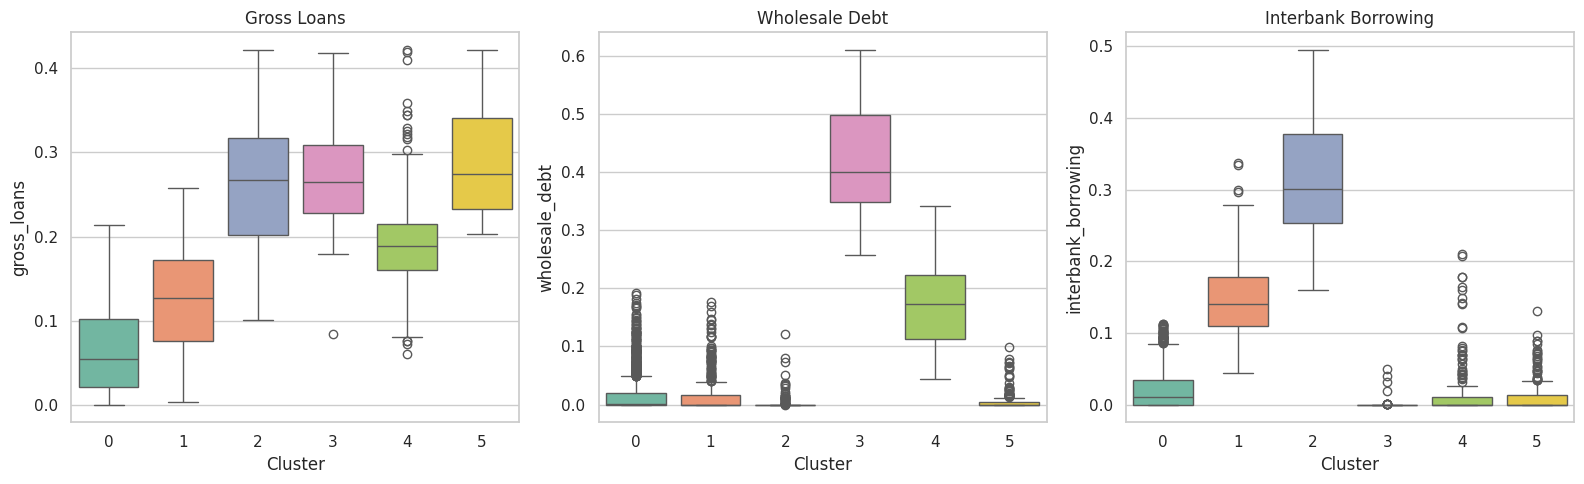

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Médias das Variáveis por Cluster (Tabela Estilo BIS) ===")
# Multiplicando por 100 para visualizar em percentual do Ativo Total
summary_table = (X_scaled.groupby('Cluster')[['gross_loans', 'wholesale_debt', 'interbank_borrowing', 'customer_deposits']].mean() * 100).round(2)
summary_table['Quantidade'] = X_scaled.groupby('Cluster').size()
print(summary_table)

# Visualizando as proporções
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Cluster', y='gross_loans', data=X_scaled, ax=axes[0], palette='Set2')
axes[0].set_title('Gross Loans')

sns.boxplot(x='Cluster', y='wholesale_debt', data=X_scaled, ax=axes[1], palette='Set2')
axes[1].set_title('Wholesale Debt')

sns.boxplot(x='Cluster', y='interbank_borrowing', data=X_scaled, ax=axes[2], palette='Set2')
axes[2].set_title('Interbank Borrowing')

plt.tight_layout()
plt.show()

